# NB04: Core vs Accessory Status (H3)

**Hypothesis H3**: PGP genes are predominantly accessory (non-core) within their carrier species, consistent with lateral gene transfer as the primary acquisition mechanism.

**Steps:**
1. For each PGP gene: count clusters as core / auxiliary / singleton
2. Compare to genome-wide baseline from pangenome table
3. Chi-square test: PGP gene core/accessory distribution vs genome-wide baseline
4. Correlation: pangenome openness (singleton_fraction) vs PGP gene count per species
5. Pie charts per gene + summary figure

**Input**: `data/pgp_clusters.csv`, `data/pangenome_stats.csv`, `data/species_pgp_matrix.csv`

**Output**: `data/pgp_core_accessory.csv`, `figures/pgp_core_accessory_pie.png`, `figures/openness_vs_pgp.png`

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'pgp_pangenome_ecology')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

pgp_clusters = pd.read_csv(os.path.join(DATA, 'pgp_clusters.csv'))
pangenome_stats = pd.read_csv(os.path.join(DATA, 'pangenome_stats.csv'))
species_pgp = pd.read_csv(os.path.join(DATA, 'species_pgp_matrix.csv'))

print(f'PGP clusters: {len(pgp_clusters):,}')
print(f'Pangenome stats: {len(pangenome_stats):,} species')
print(f'Species PGP matrix: {len(species_pgp):,} species')

PGP clusters: 32,736
Pangenome stats: 27,702 species
Species PGP matrix: 11,272 species


## 1. Genome-wide baseline

In [2]:
# Genome-wide core/aux/singleton fractions
# Weighted by cluster count across all species
total_core = pangenome_stats['no_core'].sum()
total_aux = pangenome_stats['no_aux_genome'].sum()
total_singleton = pangenome_stats['no_singleton_gene_clusters'].sum()
total_clusters = pangenome_stats['no_gene_clusters'].sum()

baseline_core_frac = total_core / total_clusters
baseline_aux_frac = total_aux / total_clusters
baseline_singleton_frac = total_singleton / total_clusters

print('Genome-wide cluster baseline:')
print(f'  Core:      {total_core:>12,}  ({baseline_core_frac*100:.1f}%)')
print(f'  Auxiliary: {total_aux:>12,}  ({baseline_aux_frac*100:.1f}%)')
print(f'  Singleton: {total_singleton:>12,}  ({baseline_singleton_frac*100:.1f}%)')
print(f'  Total:     {total_clusters:>12,}')

Genome-wide cluster baseline:
  Core:        62,062,686  (46.8%)
  Auxiliary:   70,468,815  (53.2%)
  Singleton:   50,203,195  (37.9%)
  Total:      132,531,501


## 2. Per-gene core/accessory breakdown

In [3]:
PGP_GENES = ['nifH', 'nifD', 'nifK', 'acdS', 'pqqA', 'pqqB', 'pqqC', 'pqqD', 'pqqE',
             'ipdC', 'hcnA', 'hcnB', 'hcnC']

gene_ca = []
for gene in PGP_GENES:
    sub = pgp_clusters[pgp_clusters['gene'] == gene]
    if len(sub) == 0:
        continue
    n_total = len(sub)
    n_core = sub['is_core'].sum()
    # Auxiliary = is_auxiliary & ~is_singleton (true auxiliary)
    n_aux = (sub['is_auxiliary'] & ~sub['is_singleton']).sum()
    n_singleton = sub['is_singleton'].sum()
    
    # Chi-square vs genome-wide baseline
    observed = [n_core, n_aux + n_singleton]  # core vs non-core
    expected_frac = [baseline_core_frac, 1 - baseline_core_frac]
    expected = [n_total * f for f in expected_frac]
    chi2, p_chi = stats.chisquare(observed, f_exp=expected)
    
    gene_ca.append({
        'gene': gene, 'n_total': n_total,
        'n_core': int(n_core), 'n_aux': int(n_aux), 'n_singleton': int(n_singleton),
        'pct_core': n_core / n_total * 100,
        'pct_aux': n_aux / n_total * 100,
        'pct_singleton': n_singleton / n_total * 100,
        'pct_accessory': (n_aux + n_singleton) / n_total * 100,
        'chi2_vs_baseline': chi2, 'p_vs_baseline': p_chi
    })

gene_ca_df = pd.DataFrame(gene_ca)
_, q_ca, _, _ = multipletests(gene_ca_df['p_vs_baseline'], method='fdr_bh')
gene_ca_df['q_vs_baseline'] = q_ca

print(f'Genome-wide baseline: {baseline_core_frac*100:.1f}% core, '
      f'{(1-baseline_core_frac)*100:.1f}% non-core')
print()
print(gene_ca_df[['gene', 'n_total', 'pct_core', 'pct_aux', 'pct_singleton',
                   'pct_accessory', 'q_vs_baseline']].to_string(index=False))

gene_ca_df.to_csv(os.path.join(DATA, 'pgp_core_accessory.csv'), index=False)
print(f'\nSaved pgp_core_accessory.csv')

Genome-wide baseline: 46.8% core, 53.2% non-core

gene  n_total  pct_core   pct_aux  pct_singleton  pct_accessory  q_vs_baseline
nifH     2756 63.824383 15.130624      21.044993      36.175617   4.332246e-71
nifD     1952 63.934426 17.930328      18.135246      36.065574   1.753330e-51
nifK     1431 65.688330 16.282320      18.029350      34.311670   3.685973e-46
acdS      476 70.378151 13.445378      16.176471      29.621849   7.913591e-25
pqqA     1332 61.336336 16.816817      21.846847      38.663664   3.130695e-26
pqqB     2883 78.078391  8.949011      12.972598      21.921609  3.037814e-247
pqqC     3028 81.472919  7.793923      10.733157      18.527081   0.000000e+00
pqqD    13055 55.457679 16.997319      27.545002      44.542321   2.197680e-86
pqqE     3599 76.104473  8.363434      15.532092      23.895527  1.444398e-270
ipdC      226 76.548673  9.734513      13.716814      23.451327   3.433476e-19
hcnA      400 78.500000 10.750000      10.750000      21.500000   9.208617e-37
hc

## 3. Pie charts per gene

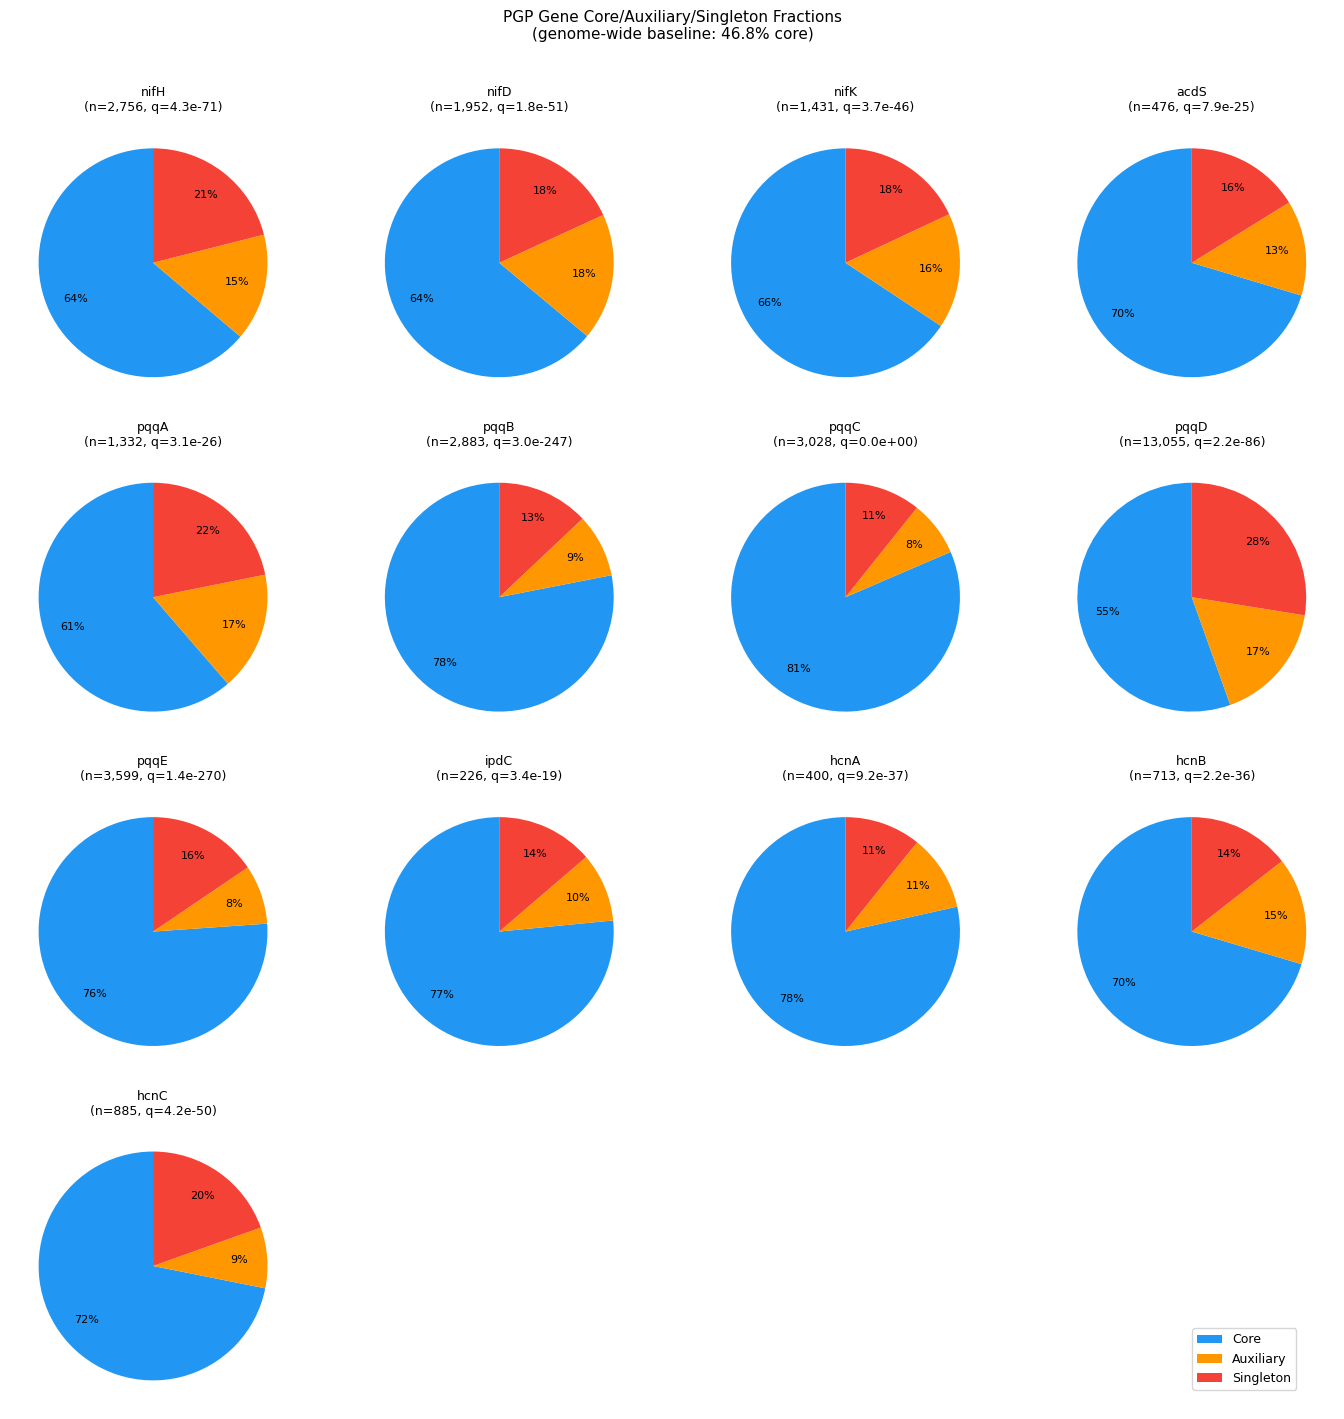

Saved figures/pgp_core_accessory_pie.png


In [4]:
n_genes = len(gene_ca_df)
ncols = 4
nrows = (n_genes + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
axes = axes.flatten()

COLORS = ['#2196F3', '#FF9800', '#F44336']  # core, aux, singleton

for i, (_, row) in enumerate(gene_ca_df.iterrows()):
    ax = axes[i]
    sizes = [row['pct_core'], row['pct_aux'], row['pct_singleton']]
    labels = ['Core', 'Auxiliary', 'Singleton']
    wedges, texts, autotexts = ax.pie(
        sizes, labels=None, colors=COLORS, autopct='%1.0f%%',
        startangle=90, pctdistance=0.75
    )
    for at in autotexts:
        at.set_fontsize(8)
    q_str = f'q={row["q_vs_baseline"]:.1e}' if row['q_vs_baseline'] < 0.05 else 'ns'
    ax.set_title(f'{row["gene"]}\n(n={int(row["n_total"]):,}, {q_str})', fontsize=9)

# Hide unused subplots
for i in range(n_genes, len(axes)):
    axes[i].set_visible(False)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for c, l in zip(COLORS, ['Core', 'Auxiliary', 'Singleton'])]
fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.95, 0.02), fontsize=9)

# Add baseline line indicator
fig.suptitle(
    f'PGP Gene Core/Auxiliary/Singleton Fractions\n'
    f'(genome-wide baseline: {baseline_core_frac*100:.1f}% core)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'pgp_core_accessory_pie.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/pgp_core_accessory_pie.png')

## 4. Pangenome openness vs PGP gene richness

In [5]:
# Correlation: pangenome openness (singleton_fraction) vs PGP gene count
merged = species_pgp.merge(
    pangenome_stats[['gtdb_species_clade_id', 'singleton_fraction', 'accessory_fraction',
                      'core_fraction', 'no_genomes']],
    on='gtdb_species_clade_id', how='inner'
)

# Filter species with >=2 genomes (singleton_fraction meaningful)
merged_multi = merged[merged['no_genomes'] >= 2].copy()

print(f'Species with pangenome stats and PGP data: {len(merged_multi):,}')

rho_sing, p_sing = stats.spearmanr(merged_multi['singleton_fraction'], merged_multi['n_pgp_genes'])
rho_acc, p_acc = stats.spearmanr(merged_multi['accessory_fraction'], merged_multi['n_pgp_genes'])
print(f'\nSpearman correlation (singleton_fraction vs n_pgp_genes): rho={rho_sing:.3f}, p={p_sing:.2e}')
print(f'Spearman correlation (accessory_fraction vs n_pgp_genes): rho={rho_acc:.3f}, p={p_acc:.2e}')

Species with pangenome stats and PGP data: 11,272

Spearman correlation (singleton_fraction vs n_pgp_genes): rho=-0.195, p=1.97e-97
Spearman correlation (accessory_fraction vs n_pgp_genes): rho=-0.147, p=2.07e-55


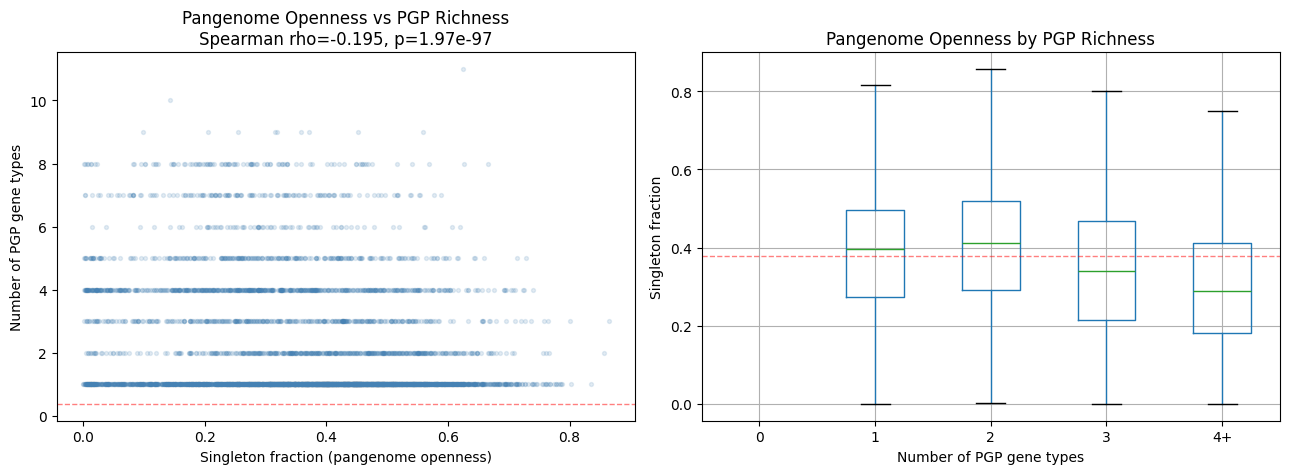

Saved figures/openness_vs_pgp.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter openness vs PGP count (sample if large)
ax = axes[0]
plot_df = merged_multi.sample(min(5000, len(merged_multi)), random_state=42)
ax.scatter(plot_df['singleton_fraction'], plot_df['n_pgp_genes'],
           alpha=0.15, s=8, color='steelblue')
ax.set_xlabel('Singleton fraction (pangenome openness)')
ax.set_ylabel('Number of PGP gene types')
ax.set_title(f'Pangenome Openness vs PGP Richness\nSpearman rho={rho_sing:.3f}, p={p_sing:.2e}')

# Right: boxplot of singleton_fraction by n_pgp_genes (binned)
ax = axes[1]
merged_multi['pgp_bin'] = pd.cut(merged_multi['n_pgp_genes'],
                                  bins=[-1, 0, 1, 2, 3, 100],
                                  labels=['0', '1', '2', '3', '4+'])
merged_multi.boxplot(column='singleton_fraction', by='pgp_bin', ax=ax,
                      notch=False, showfliers=False)
ax.set_xlabel('Number of PGP gene types')
ax.set_ylabel('Singleton fraction')
ax.set_title('Pangenome Openness by PGP Richness')
plt.suptitle('')  # remove automatic title from boxplot

for ax_i in axes:
    ax_i.axhline(baseline_singleton_frac, color='red', linestyle='--',
                  alpha=0.5, linewidth=1, label='Genome-wide mean')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'openness_vs_pgp.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/openness_vs_pgp.png')

In [7]:
print('=== H3 Summary: Core vs Accessory Status ===')
print(f'Genome-wide baseline: {baseline_core_frac*100:.1f}% core, {(1-baseline_core_frac)*100:.1f}% non-core')
print()
predominantly_accessory = gene_ca_df[gene_ca_df['pct_accessory'] > 50]
print(f'PGP genes >50% accessory: {len(predominantly_accessory):,} / {len(gene_ca_df)}')
print(f'Mean accessory fraction across PGP genes: {gene_ca_df["pct_accessory"].mean():.1f}%')
sig_more_accessory = gene_ca_df[
    (gene_ca_df['q_vs_baseline'] < 0.05) &
    (gene_ca_df['pct_accessory'] > (1 - baseline_core_frac) * 100)
]
print(f'Significantly more accessory than baseline: {len(sig_more_accessory):,}')
print()
print(f'Openness-PGP correlation: rho={rho_sing:.3f} (singleton_fraction vs PGP richness)')
h3_supported = len(predominantly_accessory) >= 3
print(f'\nH3 supported (>=3 genes predominantly accessory): {h3_supported}')

=== H3 Summary: Core vs Accessory Status ===
Genome-wide baseline: 46.8% core, 53.2% non-core

PGP genes >50% accessory: 0 / 13
Mean accessory fraction across PGP genes: 29.7%
Significantly more accessory than baseline: 0

Openness-PGP correlation: rho=-0.195 (singleton_fraction vs PGP richness)

H3 supported (>=3 genes predominantly accessory): False
